In [213]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

departments = pd.read_csv("departments.csv")
diagnosis = pd.read_csv("diagnosis.csv")
encounters = pd.read_csv("encounters.csv")
patients = pd.read_csv("patients.csv")
providers = pd.read_csv("providers.csv")
social_determinants = pd.read_csv("social_determinants.csv")
tigercensuscodes = pd.read_csv("tigercensuscodes.csv")

/var/folders/gp/m5jhv8y904l6263shvkxvlq40000gn/T/ipykernel_7057/107363113.py:11: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  social_determinants = pd.read_csv("social_determinants.csv")


## Null Values

In [14]:
print(departments.shape[0])
departments.isnull().sum()

11597


DepartmentKey             0
Address                2884
City                   2204
County                  574
DepartmentName            0
DepartmentSpecialty     574
DepartmentType          574
PostalCode             3009
CensusTract            4575
dtype: int64

In [13]:
print(diagnosis.shape[0])
diagnosis.isnull().sum()

1531262


DiagnosisKey      0
GroupName         0
GroupCode         0
DiagnosisName     0
DiagnosisValue    0
dtype: int64

In [12]:
print(encounters.shape[0])
encounters.isnull().sum()

7675801


Date                                 0
AdmissionInstant               6627001
AdmitYear                      6627001
AdmitMonth                     6627001
AdmitDay                       6627001
AdmitHour                      6627001
AdmitMinute                    6627001
AdmissionSource                   1400
AdmissionType                     1086
DischargeInstant               6627001
DischargeYear                  6627001
DischargeMonth                 6627001
DischargeDay                   6627001
DischargeHour                  6627001
DischargeMinute                6627001
EncounterKey                         0
PatientDurableKey                    0
Type                                 0
VisitType                            0
VisitTypeDescription                 0
ProviderDurableKey                   0
AttendingProviderDurableKey          0
DischargeProviderDurableKey          0
DepartmentKey                        0
PrimaryDiagnosisKey                  0
IsEdVisit                

In [11]:
print(patients.shape[0])
patients.isnull().sum()

947685


CensusBlockGroupFipsCode         0
DurableKey                       0
FirstRace                   365398
MaritalStatus                    0
MyChartStatus                    0
OmbEthnicity                     0
OmbRace                          0
SexAssignedAtBirth               0
SexualOrientation                0
SmokingStatus                    0
VitalStatus                      0
PatientBirthYearBin           1725
dtype: int64

In [10]:
print(providers.shape[0])
providers.isnull().sum()

299075


DurableKey                0
ClinicianTitle       113067
OfficeAddress         30335
OfficeCity            30344
OfficePostalCode      30362
PrimaryDepartment         0
PrimarySpecialty      37856
Type                      0
dtype: int64

In [39]:
supporting = pd.read_csv("Social Determinant Questions and Domains.csv")
social_determinants_supported = pd.merge(social_determinants, supporting)

print(social_determinants_supported.shape[0])
social_determinants_supported.isnull().sum()

725197


DisplayName          0
AnswerText           0
EncounterKey         0
PatientDurableKey    0
Domain               0
dtype: int64

In [16]:
print(tigercensuscodes.shape[0])
tigercensuscodes.isnull().sum()

2463


GEOID              0
PopulationValue    2
CENTLAT            2
CENTLON            2
dtype: int64

## County Population Counts

In [170]:
county_mapping = pd.DataFrame({
    "CountyCode": [
        "001","003","005","007","009","011","013","015","017","019","021","023","025","027",
        "029","031","033","035","037","039","041","043","045","047","049","051","053","055",
        "057","059","061","063","065","067","069","071","073","075","077","079","081","083",
        "085","087","089","091","093","095","097","099","101","103","105","107","109","111",
        "113","115","117","119","121","123","125","127","129","131","133","135","137","139",
        "141","143","145","147","149","151","153","155","157","159","161","163","165","167",
        "169","171","173","175","177","179","181","183","185","187","189","191","193","195",
        "197","199","201","203","205","207","209"
    ],
    "CountyName": [
        "Allen","Anderson","Atchison","Barber","Barton","Bourbon","Brown","Butler","Chase",
        "Chautauqua","Cherokee","Cheyenne","Clark","Clay","Cloud","Coffey","Comanche","Cowley",
        "Crawford","Decatur","Dickinson","Doniphan","Douglas","Edwards","Elk","Ellis","Ellsworth",
        "Finney","Ford","Franklin","Geary","Gove","Graham","Grant","Gray","Greeley","Greenwood",
        "Hamilton","Harper","Harvey","Haskell","Hodgeman","Jackson","Jefferson","Jewell",
        "Johnson","Kearny","Kingman","Kiowa","Labette","Lane","Leavenworth","Lincoln","Linn",
        "Logan","Lyon","McPherson","Marion","Marshall","Meade","Miami","Mitchell","Montgomery",
        "Morris","Morton","Nemaha","Neosho","Ness","Norton","Osage","Osborne","Ottawa","Pawnee",
        "Phillips","Pottawatomie","Pratt","Rawlins","Reno","Republic","Rice","Riley","Rooks",
        "Rush","Russell","Saline","Scott","Sedgwick","Seward","Shawnee","Sheridan","Sherman",
        "Smith","Stafford","Stanton","Stevens","Sumner","Thomas","Trego","Wabaunsee","Wallace",
        "Washington","Wichita","Wilson","Woodson","Wyandotte"
    ]
})

In [199]:
patients = patients[
    patients["CensusBlockGroupFipsCode"].notna() &
    (patients["CensusBlockGroupFipsCode"] != "*Unspecified")
] # removing patients with null or unspecified census block group information - unsure whether or not to do this 

tigercensuscodes.head()

tigercensuscodes["GEOID"] = tigercensuscodes["GEOID"].astype(str)
tigercensuscodes["CountyFips"] = tigercensuscodes["GEOID"].str[:5]


tiger_geo = tigercensuscodes[[
    "GEOID",
    "CountyFips",
    "CENTLAT",
    "CENTLON",
    "PopulationValue"
]]


patients_geo = patients.merge(
    tiger_geo,
    left_on="CensusBlockGroupFipsCode",
    right_on="GEOID",
    how="left"
)

patients_geo["CountyCode"] = patients_geo["CountyFips"].str[-3:]
patients_geo.head()

,CensusBlockGroupFipsCode,DurableKey,FirstRace,MaritalStatus,MyChartStatus,OmbEthnicity,OmbRace,SexAssignedAtBirth,SexualOrientation,SmokingStatus,VitalStatus,PatientBirthYearBin,GEOID,CountyFips,CENTLAT,CENTLON,PopulationValue,CountyCode
0,201770007002,5.0,White or Caucasian,Single,Activated,Not Hispanic or Latino,White,*Unspecified,*Unspecified,Never,Alive,1970.0,201770007002,20177,39.085523,-95.701250,1677.0,177
1,201770030011,15.0,White or Caucasian,Single,Activated,Not Hispanic or Latino,White,*Unspecified,*Unspecified,Every Day,Alive,1985.0,201770030011,20177,39.011938,-95.658068,1683.0,177
2,200850826001,17.0,White or Caucasian,Married,Activated,Asked but No Answer,White,*Unspecified,*Unspecified,Never,Alive,1960.0,200850826001,20085,39.306428,-95.655482,1757.0,085
3,201770016032,19.0,White or Caucasian,Single,Pending Activation,Unknown,White,*Unspecified,*Unspecified,Never Assessed,Alive,2000.0,201770016032,20177,39.008475,-95.722758,1423.0,177
4,201314802002,45.0,White or Caucasian,Married,Activated,Not Hispanic or Latino,White,*Unspecified,*Unspecified,Former,Alive,1970.0,201314802002,20131,39.844185,-96.071251,1421.0,131


In [201]:
region_map = {
    "Shawnee": "Northeast Kansas",
    "Jefferson": "Northeast Kansas",
    "Riley": "Northeast Kansas",
    "Lyon": "Northeast Kansas",
    "Douglas": "Northeast Kansas",
    "Osage": "Northeast Kansas",
    "Nemaha": "Northeast Kansas",
    "Wabaunsee": "Northeast Kansas",
    "Pottawatomie": "Northeast Kansas",
    "Jackson": "Northeast Kansas",
    "Johnson": "Northeast Kansas",
    "Franklin": "Northeast Kansas",
    "Coffey": "Northeast Kansas",
    "Chase": "Northeast Kansas",
    "Atchison": "Northeast Kansas",
    "Geary": "Northeast Kansas",
    "Wyandotte": "Northeast Kansas",
    "Marshall": "Northeast Kansas",
    "Morris": "Northeast Kansas",
    "Leavenworth": "Northeast Kansas",
    "Brown": "Northeast Kansas",
    "Doniphan": "Northeast Kansas",
    "Miami": "Northeast Kansas",

    "Cheyenne": "Northwest Kansas",
    "Rawlins": "Northwest Kansas",
    "Decatur": "Northwest Kansas",
    "Norton": "Northwest Kansas",
    "Phillips": "Northwest Kansas",
    "Sherman": "Northwest Kansas",
    "Thomas": "Northwest Kansas",
    "Sheridan": "Northwest Kansas",
    "Graham": "Northwest Kansas",
    "Rooks": "Northwest Kansas",
    "Wallace": "Northwest Kansas",
    "Logan": "Northwest Kansas",
    "Gove": "Northwest Kansas",
    "Trego": "Northwest Kansas",
    "Ellis": "Northwest Kansas",

    "Smith": "North Central Kansas",
    "Jewell": "North Central Kansas",
    "Republic": "North Central Kansas",
    "Washington": "North Central Kansas",
    "Osborne": "North Central Kansas",
    "Mitchell": "North Central Kansas",
    "Cloud": "North Central Kansas",
    "Clay": "North Central Kansas",
    "Lincoln": "North Central Kansas",
    "Ottawa": "North Central Kansas",
    "Russell": "North Central Kansas",
    "Saline": "North Central Kansas",
    "Ellsworth": "North Central Kansas",
    "Dickinson": "North Central Kansas",

    "Ford": "Southwest Kansas",
    "Finney": "Southwest Kansas",
    "Scott": "Southwest Kansas",
    "Grant": "Southwest Kansas",
    "Pratt": "Southwest Kansas",
    "Edwards": "Southwest Kansas",
    "Barber": "Southwest Kansas",
    "Ness": "Southwest Kansas",

    "Sedgwick": "South Central Kansas",
    "McPherson": "South Central Kansas",
    "Harvey": "South Central Kansas",
    "Cowley": "South Central Kansas",
    "Butler": "South Central Kansas",
    "Pawnee": "South Central Kansas",
    "Reno": "South Central Kansas",
    "Rush": "South Central Kansas",
    "Barton": "South Central Kansas",
    "Rice": "South Central Kansas",
    "Harper": "South Central Kansas",
    "Stafford": "South Central Kansas",

    "Woodson": "Southeast Kansas",
    "Greenwood": "Southeast Kansas",
    "Neosho": "Southeast Kansas",
    "Allen": "Southeast Kansas",
    "Wilson": "Southeast Kansas",
    "Labette": "Southeast Kansas",
    "Montgomery": "Southeast Kansas",
    "Crawford": "Southeast Kansas",
    "Chautauqua": "Southeast Kansas",
    "Bourbon": "Southeast Kansas",
    "Elk": "Southeast Kansas",
    "Linn": "Southeast Kansas",
    "Anderson": "Southeast Kansas"
}

region_df = pd.DataFrame(region_map.items(), columns = ["County", "Region"])
region_df = pd.merge(region_df, county_mapping, left_on = "County", right_on = "CountyName").drop(columns = "CountyName")
region_df.head()

,County,Region,CountyCode
0,Shawnee,Northeast Kansas,177
1,Jefferson,Northeast Kansas,087
2,Riley,Northeast Kansas,161
3,Lyon,Northeast Kansas,111
4,Douglas,Northeast Kansas,045


## Cancer

In [247]:
df = pd.merge(encounters, diagnosis, left_on='PrimaryDiagnosisKey', right_on='DiagnosisKey')
df['CANCER'] = df['GroupName'].str.contains('malignant', case=False, na=False).astype(int)
cancer_df = df.loc[df["CANCER"] == 1]
cancer_df["Date"] = pd.to_datetime(cancer_df["Date"], format='mixed')

/var/folders/gp/m5jhv8y904l6263shvkxvlq40000gn/T/ipykernel_7057/3029262007.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cancer_df["Date"] = pd.to_datetime(cancer_df["Date"], format='mixed')


In [248]:
# df should be a sub-dataframe of encounters with all encounters involving the relevant diagnoses
# in your input df, make sure you change the "Date" column to datetime objects
def time_between_visits(df):
    results = []
    for patient_key in df["PatientDurableKey"].unique():
        patient_df = df.loc[df["PatientDurableKey"] == patient_key].sort_values(by = "Date", ascending = True)
        
        if len(patient_df) == 1:
            avg_wait = pd.to_timedelta(0, unit = 's')
            
        else: 
            time_btwn = []
            for i in range(0, len(patient_df) - 1):
                time_btwn.append(patient_df.iloc[i+1, 0] - patient_df.iloc[i, 0])
            avg_wait = np.mean(time_btwn)

        results.append({"Patient Key": patient_key, "Avg Wait Time": avg_wait})

    return pd.DataFrame(results)

In [249]:
cancer_waittime_df = time_between_visits(cancer_df)

In [151]:
# filter out patients that only had 1 appointment
cancer_waittime_df = cancer_waittime_df.loc[cancer_waittime_df["Avg Wait Time"] != pd.Timedelta(0, unit = 's')]

In [128]:
q1 = np.percentile(cancer_waittime_df["Avg Wait Time"], 25)
q3 = np.percentile(cancer_waittime_df["Avg Wait Time"], 75)

IQR = q3 - q1

upper_fence = q3 + 1.5 * IQR
lower_fence = q1 - 1.5 * IQR

outlier_bool = (cancer_waittime_df["Avg Wait Time"] > upper_fence) | (cancer_waittime_df["Avg Wait Time"] < lower_fence)
outliers_cancer = cancer_waittime_df.loc[outlier_bool]

cancer_wt_clean = cancer_waittime_df[~ cancer_waittime_df["Patient Key"].isin(outliers_cancer["Patient Key"])]

In [203]:
cancer_county_df = pd.merge(cancer_wt_clean, patients_geo[["DurableKey", "CountyCode"]], left_on = 'Patient Key', right_on = 'DurableKey', how = 'inner')
cancer_county_df = cancer_county_df[["Patient Key", "Avg Wait Time", "CountyCode"]]

cancer_county_region = pd.merge(cancer_county_df, region_df, on = "CountyCode")
cancer_county_region.head()

,Patient Key,Avg Wait Time,CountyCode,County,Region
0,221635,294 days 00:00:00,177,Shawnee,Northeast Kansas
1,432065,66 days 13:12:00,177,Shawnee,Northeast Kansas
2,5715882,254 days 12:00:00,177,Shawnee,Northeast Kansas
3,6463187,435 days 00:00:00,045,Douglas,Northeast Kansas
4,6034859,126 days 02:24:00,177,Shawnee,Northeast Kansas


In [208]:
cancer_region_wt = (cancer_county_region.groupby("Region").agg(AvgWaitTime=("Avg Wait Time", "mean"), NumPatients=("Patient Key", "nunique"))
      .reset_index())

cancer_region_wt

,Region,AvgWaitTime,NumPatients
0,North Central Kansas,139 days 17:29:57.264315442,556
1,Northeast Kansas,181 days 23:09:49.060523294,55887
2,Northwest Kansas,77 days 21:17:08.571428571,14
3,South Central Kansas,143 days 06:27:11.629701062,61
4,Southeast Kansas,158 days 07:04:16.830745680,167
5,Southwest Kansas,140 days 03:20:00,6


In [210]:
cancer_county_wt = (cancer_county_region.groupby("County").agg(AvgWaitTime=("Avg Wait Time", "mean"), NumPatients=("Patient Key", "nunique"))
      .reset_index())

cancer_county_wt.head()

,County,AvgWaitTime,NumPatients
0,Allen,108 days 17:55:56.307692308,10
1,Anderson,120 days 05:36:00,6
2,Atchison,127 days 13:18:03.297255044,137
3,Barton,71 days 14:40:00,3
4,Brown,112 days 17:10:55.927991172,229


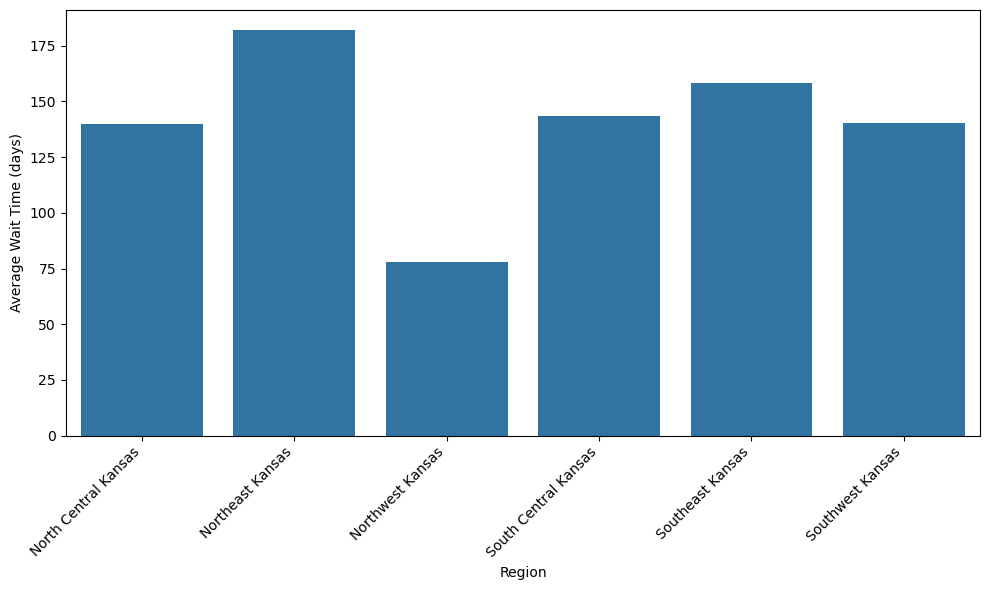

In [220]:
cancer_region_wt = cancer_region_wt.copy()
cancer_region_wt["AvgWaitDays"] = (cancer_region_wt["AvgWaitTime"].dt.total_seconds() / 86400)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=cancer_region_wt,
    x="Region",
    y="AvgWaitDays"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Wait Time (days)")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

## Fractures

In [231]:
fractures_df = df[df["GroupName"].str.contains('fracture', case = False)]
fractures_df = fractures_df[~fractures_df["GroupName"].str.contains('osteoporosis without current pathological fracture', case = False)]
fractures_df["Date"] = pd.to_datetime(fractures_df["Date"], format='mixed')

In [232]:
fractures_waittime_df = time_between_visits(fractures_df)

In [153]:
# filter out patients that only had 1 appointment
fractures_wt = fractures_waittime_df.loc[fractures_waittime_df["Avg Wait Time"] != pd.Timedelta(0, unit = 's')]

In [229]:
q1 = np.percentile(fractures_wt["Avg Wait Time"], 25)
q3 = np.percentile(fractures_wt["Avg Wait Time"], 75)

IQR = q3 - q1

upper_fence = q3 + 1.5 * IQR
lower_fence = q1 - 1.5 * IQR

outlier_bool = (fractures_wt["Avg Wait Time"] > upper_fence) | (fractures_wt["Avg Wait Time"] < lower_fence)
outliers_fractures = fractures_wt.loc[outlier_bool]

fractures_wt_clean = fractures_wt[~fractures_wt["Patient Key"].isin(outliers_fractures["Patient Key"])]

In [230]:
fractures_wt_clean.head()

,Patient Key,Avg Wait Time
0,8736284,41 days 16:30:00
8,8617181,31 days 00:00:00
11,7324148,51 days 00:00:00
32,95022,6 days 00:00:00
35,8740185,15 days 12:00:00


In [204]:
fractures_county_df = pd.merge(fractures_wt_clean, patients_geo[["DurableKey", "CountyCode"]], left_on = 'Patient Key', right_on = 'DurableKey', how = 'inner')
fractures_county_df = fractures_county_df[["Patient Key", "Avg Wait Time", "CountyCode"]]


fractures_county_region = pd.merge(fractures_county_df, region_df, on = "CountyCode")
fractures_county_region.head()

,Patient Key,Avg Wait Time,CountyCode,County,Region
0,8736284,41 days 16:30:00,177,Shawnee,Northeast Kansas
1,6121995,107 days 03:41:32.307692308,177,Shawnee,Northeast Kansas
2,6026031,343 days 00:00:00,161,Riley,Northeast Kansas
3,5564962,185 days 00:00:00,177,Shawnee,Northeast Kansas
4,6161292,159 days 15:00:00,177,Shawnee,Northeast Kansas


In [207]:
fractures_region_wt = (fractures_county_region.groupby("Region").agg(AvgWaitTime=("Avg Wait Time", "mean"), NumPatients=("Patient Key", "nunique"))
      .reset_index())

fractures_region_wt

,Region,AvgWaitTime,NumPatients
0,North Central Kansas,54 days 11:10:26.101114978,69
1,Northeast Kansas,37 days 17:57:44.396249545,7607
2,Northwest Kansas,326 days 18:00:00,2
3,South Central Kansas,256 days 00:21:15.428571428,5
4,Southeast Kansas,94 days 04:37:41.098492301,23


In [211]:
fractures_county_wt = (fractures_county_region.groupby("County").agg(AvgWaitTime=("Avg Wait Time", "mean"), NumPatients=("Patient Key", "nunique"))
      .reset_index())

fractures_county_wt.head()

,County,AvgWaitTime,NumPatients
0,Allen,5 days 06:00:00,1
1,Anderson,14 days 13:45:00,4
2,Atchison,24 days 12:07:16.717827627,22
3,Brown,26 days 15:16:36.147010884,38
4,Butler,600 days 04:17:08.571428568,2


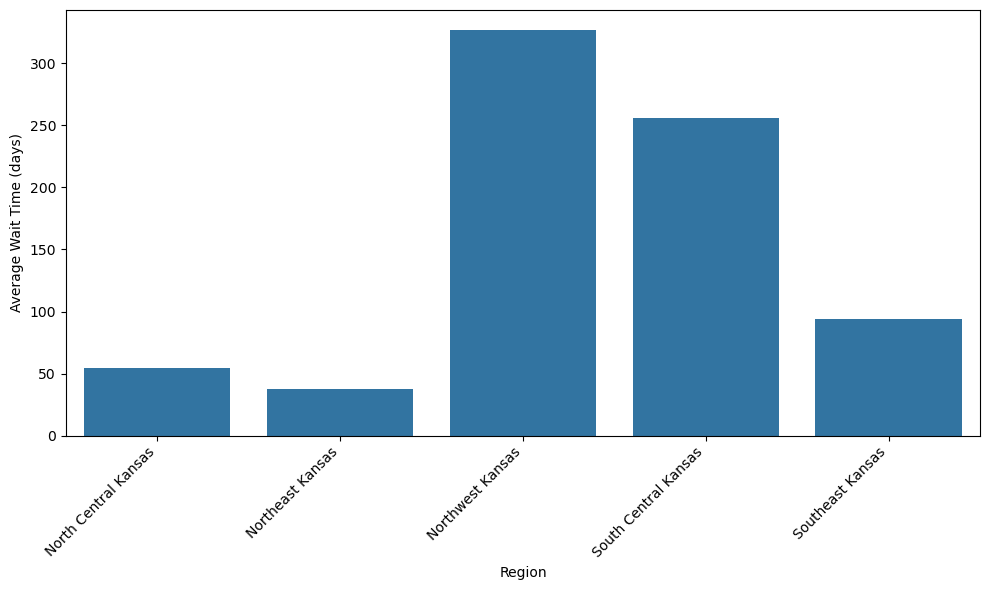

In [219]:
fractures_region_wt = fractures_region_wt.copy()
fractures_region_wt["AvgWaitDays"] = (fractures_region_wt["AvgWaitTime"].dt.total_seconds() / 86400)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=fractures_region_wt,
    x="Region",
    y="AvgWaitDays"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Wait Time (days)")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

## Depression

In [221]:
df = pd.merge(encounters, diagnosis, left_on = "PrimaryDiagnosisKey", right_on = "DiagnosisKey")
df["Depressives"] = df["GroupName"].str.contains("Depressive", case = False, na = False).astype(int)
depressives_df = df.loc[df["Depressives"] == 1]
depressives_df["Date"] = pd.to_datetime(depressives_df["Date"], format = "mixed")

/var/folders/gp/m5jhv8y904l6263shvkxvlq40000gn/T/ipykernel_7057/3994361288.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  depressives_df["Date"] = pd.to_datetime(depressives_df["Date"], format = "mixed")


In [222]:
depressives_waittime_df = time_between_visits(depressives_df)

In [228]:
# filter out patients that only had 1 appointment
depressives_wt = depressives_waittime_df.loc[depressives_waittime_df["Avg Wait Time"] != pd.Timedelta(0, unit = 's')]

In [234]:
q1 = np.percentile(depressives_wt["Avg Wait Time"], 25)
q3 = np.percentile(depressives_wt["Avg Wait Time"], 75)

IQR = q3 - q1

upper_fence = q3 + 1.5 * IQR
lower_fence = q1 - 1.5 * IQR

outlier_bool = (depressives_wt["Avg Wait Time"] > upper_fence) | (depressives_wt["Avg Wait Time"] < lower_fence)
outliers_depressives = depressives_wt.loc[outlier_bool]

depressives_wt_clean = depressives_wt[~depressives_wt["Patient Key"].isin(outliers_depressives["Patient Key"])]

In [235]:
depressives_wt_clean.head()

,Patient Key,Avg Wait Time
0,5768589,60 days 00:00:00
1,6407984,289 days 00:00:00
2,432353,266 days 12:00:00
3,456168,182 days 00:00:00
7,6004068,119 days 06:00:00


In [236]:
depressives_county_df = pd.merge(depressives_wt_clean, patients_geo[["DurableKey", "CountyCode"]], left_on = 'Patient Key', right_on = 'DurableKey', how = 'inner')
depressives_county_df = depressives_county_df[["Patient Key", "Avg Wait Time", "CountyCode"]]


depressives_county_region = pd.merge(depressives_county_df, region_df, on = "CountyCode")
depressives_county_region.head()

,Patient Key,Avg Wait Time,CountyCode,County,Region
0,5768589,60 days 00:00:00,177,Shawnee,Northeast Kansas
1,6407984,289 days 00:00:00,177,Shawnee,Northeast Kansas
2,432353,266 days 12:00:00,177,Shawnee,Northeast Kansas
3,456168,182 days 00:00:00,139,Osage,Northeast Kansas
4,7125936,350 days 00:00:00,177,Shawnee,Northeast Kansas


In [237]:
depressives_region_wt = (depressives_county_region.groupby("Region").agg(AvgWaitTime=("Avg Wait Time", "mean"), NumPatients=("Patient Key", "nunique"))
      .reset_index())

depressives_region_wt

,Region,AvgWaitTime,NumPatients
0,North Central Kansas,150 days 15:56:19.310344828,30
1,Northeast Kansas,160 days 07:22:04.427249486,3474
2,Northwest Kansas,39 days 16:00:00,3
3,South Central Kansas,186 days 01:27:16.363636364,11
4,Southeast Kansas,261 days 09:16:00,18


In [238]:
depressives_county_wt = (depressives_county_region.groupby("County").agg(AvgWaitTime=("Avg Wait Time", "mean"), NumPatients=("Patient Key", "nunique"))
      .reset_index())

depressives_county_wt.head()

,County,AvgWaitTime,NumPatients
0,Allen,193 days 00:00:00,1
1,Anderson,175 days 00:00:00,2
2,Atchison,295 days 11:26:46.153846152,13
3,Barton,328 days 12:00:00,2
4,Brown,150 days 11:18:00,4


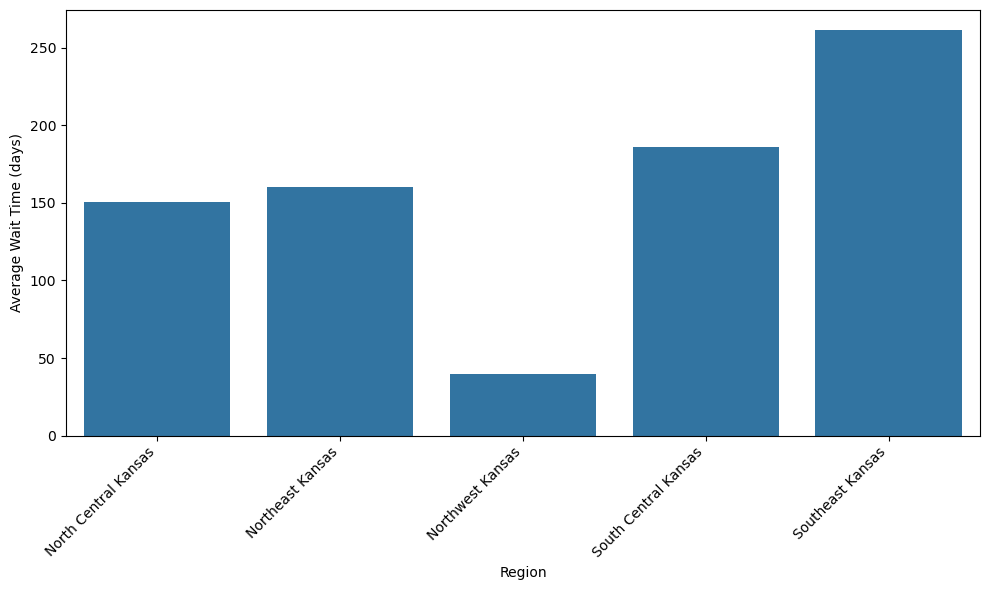

In [239]:
depressives_region_wt = depressives_region_wt.copy()
depressives_region_wt["AvgWaitDays"] = (depressives_region_wt["AvgWaitTime"].dt.total_seconds() / 86400)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=depressives_region_wt,
    x="Region",
    y="AvgWaitDays"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Wait Time (days)")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

## Overall Plot

In [251]:
cancer_region_wt.columns = ['Region', 'AvgWaitTime (Cancer)', 'NumPatients (Cancer)', 'AvgWaitDays (Cancer)']
fractures_region_wt.columns = ['Region', 'AvgWaitTime (Fractures)', 'NumPatients (Fractures)', 'AvgWaitDays (Fractures)']
depressive_region_wt.columns = ['Region', 'AvgWaitTime (Depression)', 'NumPatients (Depression)', 'AvgWaitDays (Depression)']

NameError: name 'depressive_region_wt' is not defined